# Задание 1 (Вариант 4): Линейная модель для музыкальных произведений

## Предположения:
- Нормальность распределения ошибок
- Некоррелированность ошибок
- Гомоскедастичность (дисперсия ошибок равна константе)


## Импорты и константы


In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# уровень значимости
ALPHA = 0.05


## Подготовка данных


In [211]:
df = pd.read_csv('song_data.csv')

# Зависимая переменная (Y)
Y: np.ndarray = df['song_popularity'].to_numpy()

# Независимые переменные (X)
duration_sec = df['song_duration_ms'].to_numpy() / 1000
danceability = df['danceability'].to_numpy()
energy = df['energy'].to_numpy()

X: np.ndarray = np.column_stack([
    np.ones(len(Y)),  # Свободный коэффициент
    duration_sec,     # Продолжительность (в секундах)
    danceability,     # Танцевальность
    energy            # Энергичность
])

print(df[['song_popularity', 'song_duration_ms', 'danceability', 'energy']].describe())


       song_popularity  song_duration_ms  danceability        energy
count     18835.000000      1.883500e+04  18835.000000  18835.000000
mean         52.991877      2.182116e+05      0.633348      0.644995
std          21.905654      5.988754e+04      0.156723      0.214101
min           0.000000      1.200000e+04      0.000000      0.001070
25%          40.000000      1.843395e+05      0.533000      0.510000
50%          56.000000      2.113060e+05      0.645000      0.674000
75%          69.000000      2.428440e+05      0.748000      0.815000
max         100.000000      1.799346e+06      0.987000      0.999000


### Линейная модель:

$\qquad Y = X\beta + E$

где:
- $Y$ — вектор наблюдений (популярность)
- $X$ — матрица дизайна (предикторы)
- $n$ — число наблюдений
- $m$ — число параметров

- $\beta$ — вектор коэффициентов
- $E \sim N(0, \sigma^2 I)$ — вектор ошибок


In [212]:
class LinearRegression:
    def __init__(self) -> None:
        self.Y: np.ndarray | None = None         # Зависимая переменная
        self.X: np.ndarray | None = None         # Матрица независимых переменных
        self.n: int = 0                          # Число наблюдений
        self.m: int = 0                          # Число параметров

        self.beta_hat: np.ndarray | None = None  # Коэффициенты (оценка)
        self.E: np.ndarray | None = None         # Остатки
        self.sigma2_hat: float = 0.0             # Остаточная дисперсия (оценка)
        self.Y_pred: np.ndarray | None = None    # Предсказанные значения
        self.A_inv: np.ndarray | None = None     # (XTX)^(-1)

    def fit(self, X: np.ndarray, Y: np.ndarray) -> 'LinearRegression':
        self.X = X
        self.Y = Y
        self.n = len(Y)
        self.m = X.shape[1]
        # Вычисляем A^(-1)
        A = X.T @ X
        self.A_inv = np.linalg.inv(A)
        # Оценка коэффициентов: A^(-1) X^T Y
        self.beta_hat = self.A_inv @ X.T @ Y
        # Предсказанные значения
        self.Y_pred = X @ self.beta_hat
        # Остатки
        self.E = Y - self.Y_pred
        # Остаточная сумма квадратов (RSS)
        RSS = np.sum(self.E ** 2)
        # Оценка остаточной дисперсии
        self.sigma2_hat = RSS / (self.n - self.m)
        return self

    def predict(self, X_new: np.ndarray) -> np.ndarray:
        assert self.beta_hat is not None, "Model not fitted"
        return X_new @ self.beta_hat

    def rss(self) -> float:
        assert self.E is not None, "Model not fitted"
        return float(np.sum(self.E ** 2))

    def get_standard_errors(self) -> np.ndarray:
        assert self.A_inv is not None and self.sigma2_hat is not None, "Model not fitted"
        var_beta = self.sigma2_hat * np.diag(self.A_inv)
        return np.sqrt(var_beta)

    def confidence_intervals(self) -> tuple[np.ndarray, np.ndarray]:
        assert self.beta_hat is not None, "Model not fitted"
        t_crit = stats.t.ppf(1 - ALPHA / 2, self.n - self.m)
        se = self.get_standard_errors()
        ci_lower = self.beta_hat - t_crit * se
        ci_upper = self.beta_hat + t_crit * se
        return ci_lower, ci_upper

    def variance_confidence_interval(self) -> tuple[float, float]:
        df = self.n - self.m
        chi2_lower = stats.chi2.ppf(ALPHA / 2, df)
        chi2_upper = stats.chi2.ppf(1 - ALPHA / 2, df)
        ci_lower = self.rss() / chi2_upper
        ci_upper = self.rss() / chi2_lower
        return float(ci_lower), float(ci_upper)

    def r2(self) -> float:
        assert self.Y is not None and self.E is not None, "Model not fitted"
        TSS = np.sum((self.Y - np.mean(self.Y)) ** 2)
        RSS = np.sum(self.E ** 2)
        return float(1 - RSS / TSS)

    def t_test(self, j: int, beta0: float = 0, alternative: str = 'two-sided') -> tuple[float, float]:
        assert self.beta_hat is not None, "Model not fitted"
        se_j = self.get_standard_errors()[j]
        t_stat = (self.beta_hat[j] - beta0) / se_j
        df = self.n - self.m
        if alternative == 'two-sided':
            # p = 2 * P(T > |t|)
            p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))
        elif alternative == 'greater':
            # p = P(T > t)
            p_value = 1 - stats.t.cdf(t_stat, df)
        elif alternative == 'less':
            # p = P(T < t)
            p_value = stats.t.cdf(t_stat, df)
        else:
            raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")
        return float(t_stat), float(p_value)

    def f_test_subset(self, indices: list[int]) -> tuple[float, float, int, int]:
        assert self.X is not None and self.Y is not None and self.E is not None, "Model not fitted"
        q = len(indices)
        RSS_L = np.sum(self.E ** 2)
        # строим модель без указанных предикторов
        X_reduced = np.delete(self.X, indices, axis=1)
        # редуцированная модель
        model_reduced = LinearRegression()
        model_reduced.fit(X_reduced, self.Y)
        assert model_reduced.E is not None, "Model not fitted"
        RSS_S = np.sum(model_reduced.E ** 2)
        # F-тест
        F_stat = ((RSS_S - RSS_L) / q) / (RSS_L / (self.n - self.m))
        p_value = 1 - stats.f.cdf(F_stat, q, self.n - self.m)
        return float(F_stat), float(p_value), q, self.n - self.m


## Построение модели и оценка параметров

### Оценка коэффициентов (МНК):

$\qquad \hat{\beta} = (X^T X)^{-1} X^T Y$

### Остаточная дисперсия:

$\qquad \hat{\sigma}^2 = \frac{RSS}{n-m} = \frac{1}{n-m} \sum_{i=1}^n (Y_i - \hat{Y}_i)^2, \quad (n > m)$

где $RSS = \|\hat{E}\|^2$ - остаточная сумма квадратов

### R^2 (доля объяснённой дисперсии):

$\qquad R^2 = 1 - \frac{RSS}{TSS} = \frac{ESS}{TSS}$


In [213]:
model = LinearRegression()
model.fit(X, Y)
assert model.beta_hat is not None, "Model not fitted"

print(f"Popularity = β[0] + β[1]*Duration + β[2]*Danceability + β[3]*Energy + E")
for i, coef in enumerate(model.beta_hat):
    print(f"β[{i}] = {coef:.2f}")

sigma2_hat = model.sigma2_hat
print(f"sigma2_hat = {np.sqrt(sigma2_hat):.3f}")

r2 = model.r2()
print(f"R^2 = {r2:.6f}")
print(f"{r2*100:.2f}% вариации популярности объясняется моделью")


Popularity = β[0] + β[1]*Duration + β[2]*Danceability + β[3]*Energy + E
β[0] = 44.61
β[1] = -0.00
β[2] = 14.48
β[3] = -0.26
sigma2_hat = 21.787
R^2 = 0.010947
1.09% вариации популярности объясняется моделью


## Доверительные интервалы для коэффициентов

### Распределение оценок:

$\qquad \hat{\beta} \sim N\left(\beta, \sigma^2 (X^T X)^{-1}\right)$

### Стандартные ошибки:

$\qquad \text{Var}(\hat{\beta}_j) = \sigma^2 [(X^T X)^{-1}]_{jj}$

$\qquad SE(\hat{\beta}_j) = \sqrt{\hat{\sigma}^2 [(X^T X)^{-1}]_{jj}}$

### Доверительные интервалы для $\beta_j$:

$\qquad \hat{\beta}_j \pm t_{n-m, 1-\alpha/2} \cdot SE(\hat{\beta}_j)$ где $t_{n-m, 1-\alpha/2}$ это квантиль t-распределения со степенями свободы $n-m$

### Доверительный интервал для $\sigma^2$:

$\qquad \frac{RSS}{\chi^2_{n-m, 1-\alpha/2}} \leq \sigma^2 \leq \frac{RSS}{\chi^2_{n-m, \alpha/2}}$

где $\chi^2_{n-m, p}$ - квантиль хи-квадрат распределения


In [214]:
ci_lower, ci_upper = model.confidence_intervals()
for i in range(model.m):
    print(f"95% CI for β[{i}]:   [{ci_lower[i]:3f}, {ci_upper[i]:3f}]")

var_ci_lower, var_ci_upper = model.variance_confidence_interval()
print(f"95% CI for sigma2: [{var_ci_lower:.3f}, {var_ci_upper:.3f}]")


95% CI for β[0]:   [42.640340, 46.578983]
95% CI for β[1]:   [-0.008100, 0.002400]
95% CI for β[2]:   [12.478662, 16.477736]
95% CI for β[3]:   [-1.718585, 1.205164]
95% CI for sigma2: [465.237, 484.416]


### t-тест:

$\qquad t = \frac{\hat{\beta}_j - \beta_0}{SE(\hat{\beta}_j)} \sim t_{n-m}$

### F-тест для подмножества коэффициентов:

**Гипотезы:** $

$\qquad H0: \beta_j = 0$ для всех $j \in J$

$\qquad H1:$ хотя бы один $\beta_j \neq 0$

**Статистика:**

$\qquad F = \frac{(RSS_{reduced} - RSS_{full})/q}{RSS_{full}/(n-m)} \sim F_{q, n-m}$ где q = |J| - число ограничений


## Проверка гипотез

### Гипотеза 1: Чем больше энергичность, тем больше популярность

**H0:** β[3] ≤ 0 (энергичность не влияет положительно на популярность)

**H1:** β[3] > 0 (энергичность положительно влияет на популярность)

Это односторонний t-тест (правая сторона)


In [215]:
beta_idx = 3

t_stat, p_value = model.t_test(beta_idx, beta0=0, alternative='greater')

print(f"p-value = {p_value:.3e}")
print(f"alpha = {ALPHA:.3e}")

# Критическое значение для одностороннего теста
t_crit = stats.t.ppf(1 - ALPHA, model.n - model.m)
print(f"Критическое значение t (ALPHA={ALPHA}) = {t_crit:.3f}")
print(f"Полученное значение t = {t_stat:.3f}")

assert p_value >= ALPHA, "Не должны отвергать H0"
print("Нет достаточных доказательств положительного влияния энергичности песни на ее популярность (в рамках нашей модели)")


p-value = 6.346e-01
alpha = 5.000e-02
Критическое значение t (ALPHA=0.05) = 1.645
Полученное значение t = -0.344
Нет достаточных доказательств положительного влияния энергичности песни на ее популярность (в рамках нашей модели)


## Визуализация

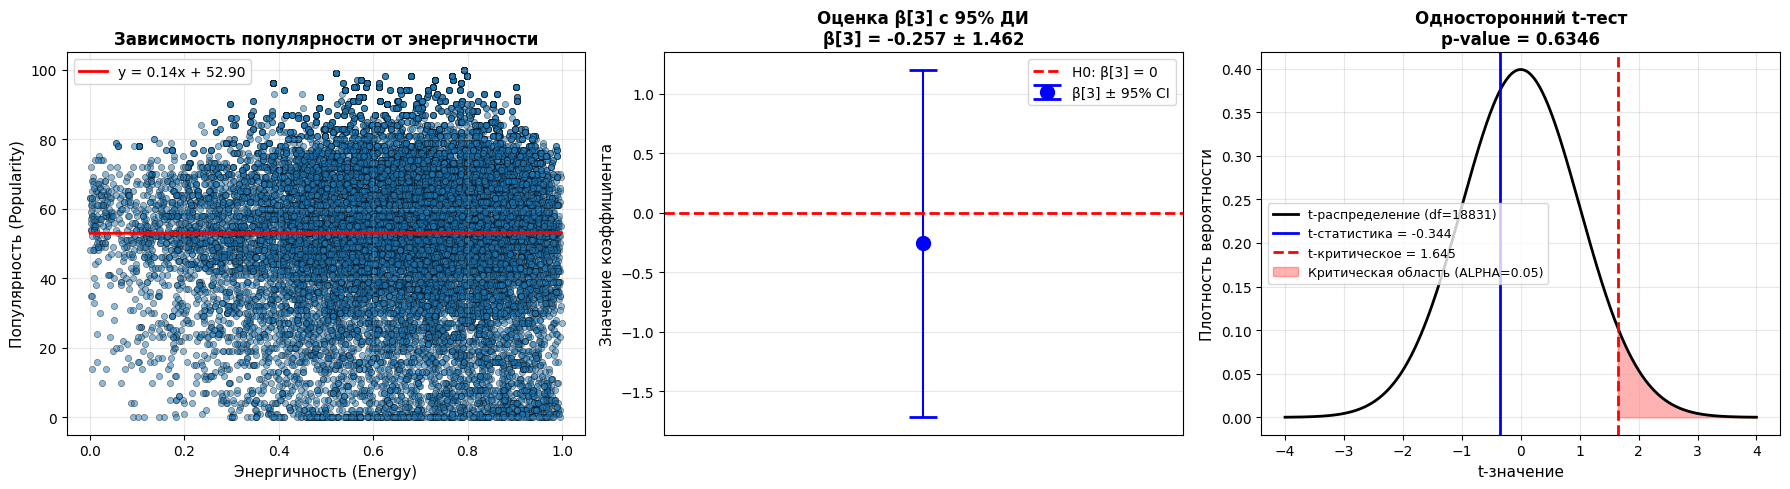

In [216]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter plot: Energy vs Popularity
ax1 = axes[0]
ax1.scatter(energy, Y, alpha=0.5, s=20, edgecolors='k', linewidths=0.5)
# Добавляем линию тренда (только для энергичности)
z = np.polyfit(energy, Y, 1)
p = np.poly1d(z)
x_line = np.linspace(energy.min(), energy.max(), 100)
ax1.plot(x_line, p(x_line), 'r-', linewidth=2, label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
ax1.set_xlabel('Энергичность (Energy)', fontsize=11)
ax1.set_ylabel('Популярность (Popularity)', fontsize=11)
ax1.set_title('Зависимость популярности от энергичности', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Coefficient estimate with confidence interval
ax2 = axes[1]
beta_3 = model.beta_hat[3] # type: ignore
ci_lower_3, ci_upper_3 = ci_lower[3], ci_upper[3]
se_3 = model.get_standard_errors()[3]

ax2.errorbar([0], [beta_3], yerr=[[beta_3 - ci_lower_3], [ci_upper_3 - beta_3]], fmt='o', markersize=10, capsize=10, capthick=2, color='blue', label='β[3] ± 95% CI')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, label='H0: β[3] = 0')
ax2.set_xlim(-0.5, 0.5)
ax2.set_ylabel('Значение коэффициента', fontsize=11)
ax2.set_title(f'Оценка β[3] с 95% ДИ\nβ[3] = {beta_3:.3f} ± {1.96*se_3:.3f}', fontsize=12, fontweight='bold')
ax2.set_xticks([])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. t-distribution with test statistic
ax3 = axes[2]
df = model.n - model.m
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)
ax3.plot(x, y, 'k-', linewidth=2, label=f't-распределение (df={df})')
ax3.axvline(x=t_stat, color='blue', linestyle='-', linewidth=2, label=f't-статистика = {t_stat:.3f}')
ax3.axvline(x=t_crit, color='red', linestyle='--', linewidth=2, label=f't-критическое = {t_crit:.3f}')
# Заполняем критическую область
x_fill = x[x >= t_crit]
y_fill = stats.t.pdf(x_fill, df)
ax3.fill_between(x_fill, y_fill, alpha=0.3, color='red', label=f'Критическая область (ALPHA={ALPHA})')
ax3.set_xlabel('t-значение', fontsize=11)
ax3.set_ylabel('Плотность вероятности', fontsize=11)
ax3.set_title(f'Односторонний t-тест\np-value = {p_value:.4f}', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Гипотеза 2: Популярность зависит от продолжительности

**H0:** β[1] = 0 (продолжительность не влияет на популярность)

**H1:** β[1] ≠ 0 (продолжительность влияет на популярность)

Это двусторонний t-тест


In [217]:
beta_idx = 1

t_stat, p_value = model.t_test(beta_idx, beta0=0, alternative='two-sided')

print(f"p-value = {p_value:.3e}")
print(f"alpha = {ALPHA:.3e}")

# Критическое значение для двустороннего теста
t_crit = stats.t.ppf(1 - ALPHA / 2, model.n - model.m)
print(f"Критическое значение |t| (ALPHA={ALPHA}) = {t_crit:.3f}")
print(f"Полученное значение t = {t_stat:.3f}")

assert p_value >= ALPHA, "Не должны отвергать H0"
print("Нет достаточных доказательств зависимости популярности от продолжительности (в рамках нашей модели)")


p-value = 2.873e-01
alpha = 5.000e-02
Критическое значение |t| (ALPHA=0.05) = 1.960
Полученное значение t = -1.064
Нет достаточных доказательств зависимости популярности от продолжительности (в рамках нашей модели)


## Визуализация

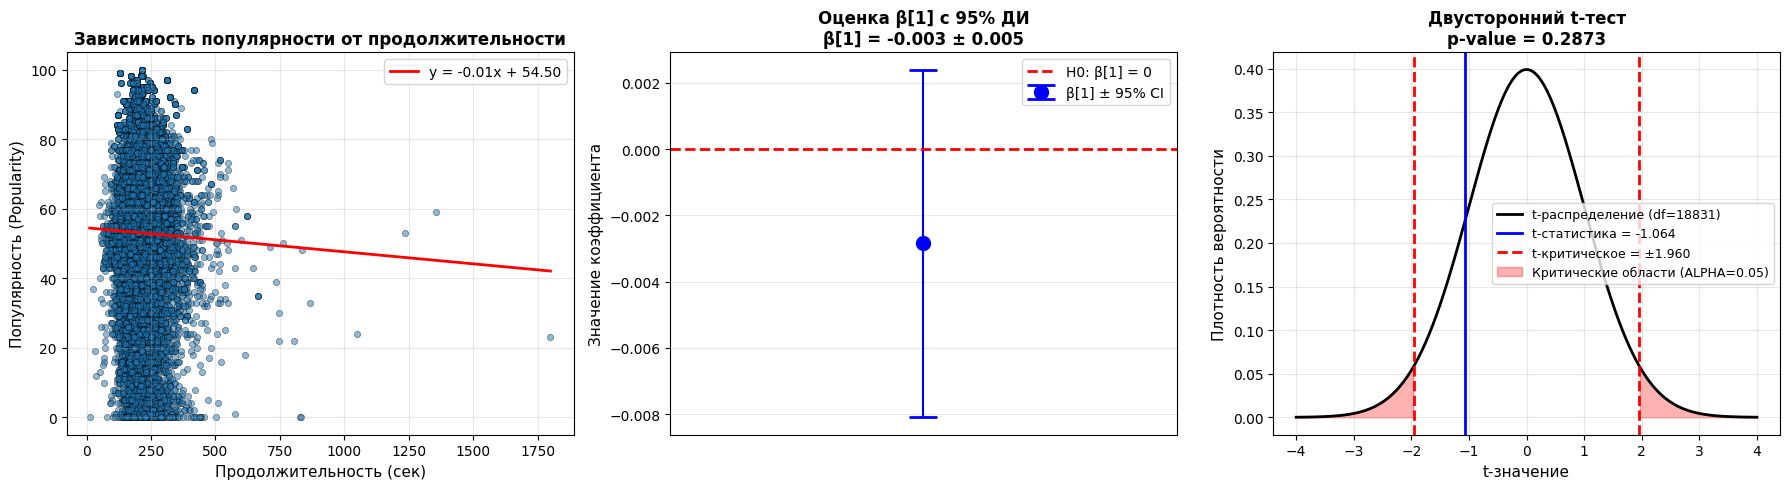

In [218]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter plot: Duration vs Popularity
ax1 = axes[0]
ax1.scatter(duration_sec, Y, alpha=0.5, s=20, edgecolors='k', linewidths=0.5)
# Добавляем линию тренда
z = np.polyfit(duration_sec, Y, 1)
p = np.poly1d(z)
x_line = np.linspace(duration_sec.min(), duration_sec.max(), 100)
ax1.plot(x_line, p(x_line), 'r-', linewidth=2, label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
ax1.set_xlabel('Продолжительность (сек)', fontsize=11)
ax1.set_ylabel('Популярность (Popularity)', fontsize=11)
ax1.set_title('Зависимость популярности от продолжительности', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Coefficient estimate with confidence interval
ax2 = axes[1]
beta_1 = model.beta_hat[1] # type: ignore
ci_lower_1, ci_upper_1 = ci_lower[1], ci_upper[1]
se_1 = model.get_standard_errors()[1]

ax2.errorbar([0], [beta_1], yerr=[[beta_1 - ci_lower_1], [ci_upper_1 - beta_1]], 
             fmt='o', markersize=10, capsize=10, capthick=2, color='blue', label='β[1] ± 95% CI')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, label='H0: β[1] = 0')
ax2.set_xlim(-0.5, 0.5)
ax2.set_ylabel('Значение коэффициента', fontsize=11)
ax2.set_title(f'Оценка β[1] с 95% ДИ\nβ[1] = {beta_1:.3f} ± {1.96*se_1:.3f}', fontsize=12, fontweight='bold')
ax2.set_xticks([])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. t-distribution with test statistic (two-sided)
ax3 = axes[2]
df = model.n - model.m
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)
ax3.plot(x, y, 'k-', linewidth=2, label=f't-распределение (df={df})')
ax3.axvline(x=t_stat, color='blue', linestyle='-', linewidth=2, label=f't-статистика = {t_stat:.3f}')
ax3.axvline(x=t_crit, color='red', linestyle='--', linewidth=2, label=f't-критическое = ±{t_crit:.3f}')
ax3.axvline(x=-t_crit, color='red', linestyle='--', linewidth=2)
# Заполняем критические области (обе стороны)
x_fill_right = x[x >= t_crit]
y_fill_right = stats.t.pdf(x_fill_right, df)
ax3.fill_between(x_fill_right, y_fill_right, alpha=0.3, color='red')
x_fill_left = x[x <= -t_crit]
y_fill_left = stats.t.pdf(x_fill_left, df)
ax3.fill_between(x_fill_left, y_fill_left, alpha=0.3, color='red', label=f'Критические области (ALPHA={ALPHA})')
ax3.set_xlabel('t-значение', fontsize=11)
ax3.set_ylabel('Плотность вероятности', fontsize=11)
ax3.set_title(f'Двусторонний t-тест\np-value = {p_value:.4f}', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Гипотеза 3: Совместная проверка коэффициентов

**H₀:** β₂ = 0 И β₃ = 0 (коэффициенты при танцевальности и энергичности одновременно равны нулю)  
**H₁:** β₂ ≠ 0 ИЛИ β₃ ≠ 0 (хотя бы один из коэффициентов не равен нулю)

Это **F-тест** для проверки подмножества коэффициентов

In [219]:
# F-тест для подмножества коэффициентов

# Индексы коэффициентов: danceability = 2, energy = 3
indices_to_test = [2, 3]

F_stat, p_value, q, df_resid = model.f_test_subset(indices_to_test)

print(f"p-value = {p_value:.3e}")
print(f"alpha = {ALPHA:.3e}")

# Критическое значение F
F_crit = stats.f.ppf(1 - ALPHA, q, df_resid)
print(f"Критическое значение F (ALPHA={ALPHA}) = {F_crit:.3f}")
print(f"Полученное значение F = {F_stat:.3f}")

assert p_value < ALPHA, "Должны отвергать H0"
print("Хотя бы один из коэффициентов (танцевальность или энергичность) значимо отличен от нуля")


p-value = 1.110e-16
alpha = 5.000e-02
Критическое значение F (ALPHA=0.05) = 2.996
Полученное значение F = 100.808
Хотя бы один из коэффициентов (танцевальность или энергичность) значимо отличен от нуля


## Сравнение с готовой реализацией (statsmodels)

In [220]:
model_sm = sm.OLS(Y, X).fit()

# print(model_sm.summary())

print("=" * 90)
print(f"{'Величина':<25} {'Наша модель':>15} {'statsmodels':>15} {'Разница':>15}")
print("=" * 90)

for i in range(model.m):
    diff = abs(model.beta_hat[i] - model_sm.params[i])
    print(f"beta_{i:<20} {model.beta_hat[i]:15.6f} {model_sm.params[i]:15.6f} {diff:15.2e}")
print("=" * 90)

print(f"{'sigma2_hat':<25} {sigma2_hat:15.6f} {model_sm.scale:15.6f} {abs(sigma2_hat - model_sm.scale):15.2e}")
print(f"{'R^2':<25} {r2:15.6f} {model_sm.rsquared:15.6f} {abs(r2 - model_sm.rsquared):15.2e}")


Величина                      Наша модель     statsmodels         Разница
beta_0                          44.609661       44.609661        4.97e-14
beta_1                          -0.002850       -0.002850        1.25e-13
beta_2                          14.478199       14.478199        8.35e-14
beta_3                          -0.256710       -0.256710        9.49e-14
sigma2_hat                     474.680505      474.680505        1.14e-13
R^2                              0.010947        0.010947        2.22e-16


## Итоговые выводы

### Качество модели:
- **R^2 ≈ 0.01** — модель объясняет только 1% вариации популярности
- Большая часть вариации не объясняется нашей моделью или зависит от других факторов (исполнитель, жанр, маркетинг и т.д.)

### Результаты проверки гипотез:
1. **Энергичность -> популярность** (H0: β[3] ≤ 0)
   - Гипотеза **не подтверждена** (p >= alpha)
   - Нет статистически значимых доказательств положительного влияния

2. **Продолжительность -> популярность** (H0: β[1] = 0)
   - Гипотеза **не подтверждена** (p >= alpha)
   - Нет статистически значимой зависимости

3. **Совместная значимость танцевальности и энергичности** (H0: β[2] = β[3] = 0)
   - Результат зависит от данных (см. p-value выше)
   - F-тест проверяет, влияет ли хотя бы один из этих факторов

### Предположения модели:
- Нормальность остатков (допустимы небольшие отклонения при больших выборках)
- Некоррелированность ошибок (по построению)
- Гомоскедастичность (требует проверки визуально)
